# 02 — Feature Engineering
## Telco Customer Churn

**Goal:** Transform raw variables into more informative features for the model.

The original dataset has 19 variables. After feature engineering we will have 100+.
Each step adds a specific type of information that the model cannot extract on its own.

| Step | Type | What it adds |
|------|------|--------------|
| 1 | Frequency Encoding | How common is each value |
| 2 | Arithmetic Interactions | Ratios and differences between charges |
| 3 | Service Counts | How many services the customer has |
| 4 | Target Encoding | Historical churn rate per group |
| 5 | Distribution Features | Where the customer sits vs churners |
| 6 | Quantile Distance | How far from typical churner behavior |
| 7 | Digit Features | Patterns in the digits of numbers |
| 8 | N-gram Features | Combinations of categorical variables |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 50)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load dataset
DATA_PATH = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(DATA_PATH)

# Standardize column names
df.columns = [col.strip() for col in df.columns]
df = df.rename(columns={'gender': 'Gender', 'tenure': 'Tenure'})

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode target
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Column groups
NUM_COLS = ['Tenure', 'MonthlyCharges', 'TotalCharges']
CAT_COLS = [
    'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Churn rate: {df["Churn"].mean()*100:.1f}%')

Dataset loaded: 7,043 rows x 21 columns
Churn rate: 26.5%


## Step 1 — Frequency Encoding

**What it does:** Replaces each numerical value with how frequently 
it appears in the dataset (as a proportion).

**Why it helps:** If a specific MonthlyCharges value appears in 40% 
of churners, that frequency itself becomes a signal for the model.

**Example:**
- Tenure = 1 month → appears in 3.2% of customers → FREQ_Tenure = 0.032
- Tenure = 72 months → appears in 1.1% of customers → FREQ_Tenure = 0.011

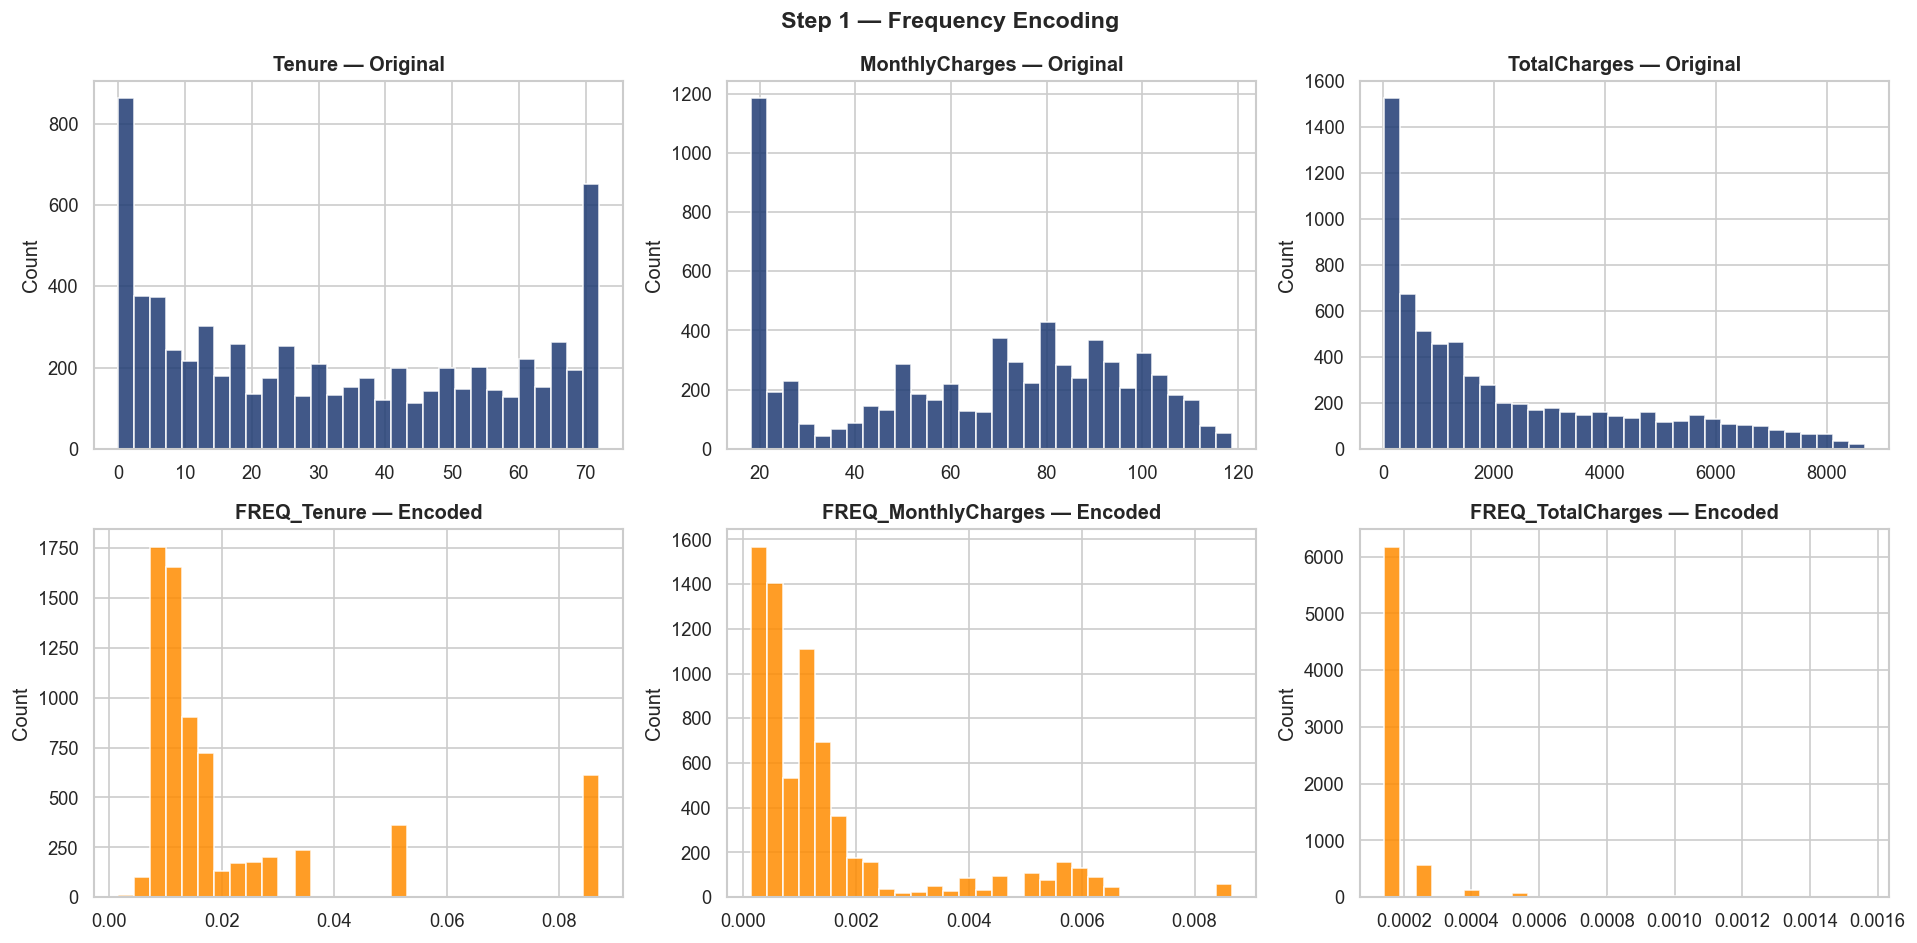

New features added: ['FREQ_Tenure', 'FREQ_MonthlyCharges', 'FREQ_TotalCharges']

Sample — FREQ_Tenure:
 Tenure  FREQ_Tenure
      0     0.001562
      1     0.087037
      2     0.033792
      3     0.028397
      4     0.024989
      5     0.018884
      6     0.015618
      7     0.018600
      8     0.017464
      9     0.016896


In [3]:
NEW_NUMS = []  # track all new numerical features

for col in NUM_COLS:
    freq = df[col].value_counts(normalize=True)
    df[f'FREQ_{col}'] = df[col].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{col}')

# Visualize — compare original vs frequency encoded
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Step 1 — Frequency Encoding', fontsize=14, weight='bold')

for i, col in enumerate(NUM_COLS):
    # Original distribution
    axes[0][i].hist(df[col], bins=30, color='#1f3b73', edgecolor='white', alpha=0.85)
    axes[0][i].set_title(f'{col} — Original', weight='bold')
    axes[0][i].set_ylabel('Count')

    # Frequency encoded
    axes[1][i].hist(df[f'FREQ_{col}'], bins=30, color='#FF8C00', edgecolor='white', alpha=0.85)
    axes[1][i].set_title(f'FREQ_{col} — Encoded', weight='bold')
    axes[1][i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/fe_01_frequency_encoding.png', dpi=150)
plt.show()

print(f'New features added: {NEW_NUMS}')
print(f'\nSample — FREQ_Tenure:')
print(df[['Tenure', 'FREQ_Tenure']].drop_duplicates().sort_values('Tenure').head(10).to_string(index=False))

## Step 2 — Arithmetic Interactions

**What it does:** Creates new features by combining existing numerical 
variables through arithmetic operations.

**Why it helps:** The model cannot automatically divide or subtract 
two columns — we need to create those relationships explicitly.

| New Feature | Formula | What it captures |
|-------------|---------|-----------------|
| `charges_deviation` | TotalCharges - (Tenure × MonthlyCharges) | Inconsistency between expected and actual total |
| `monthly_to_total_ratio` | MonthlyCharges / (TotalCharges + 1) | How much of total is current monthly charge |
| `avg_monthly_charges` | TotalCharges / (Tenure + 1) | Average monthly charge over customer lifetime |

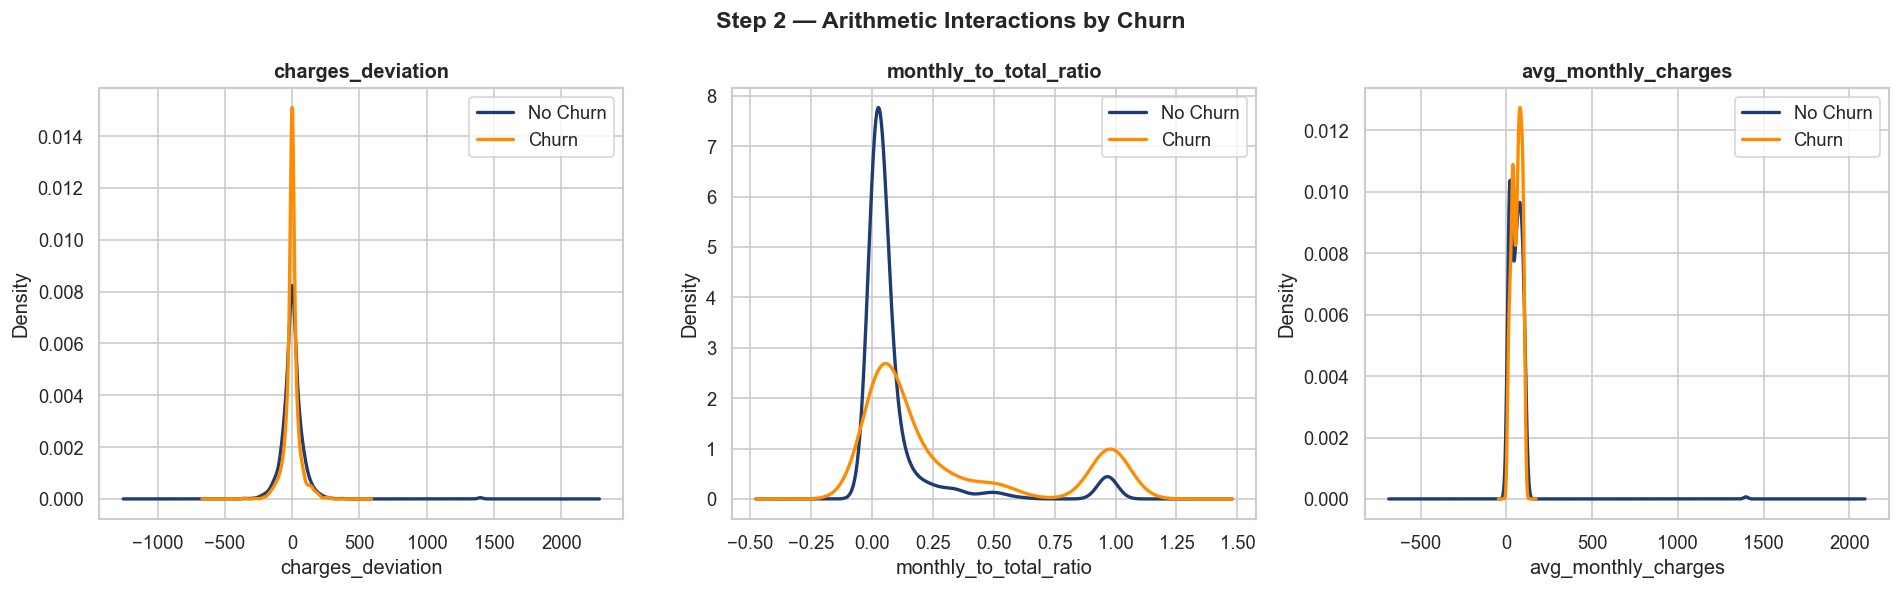

Mean values by Churn status:
       charges_deviation  monthly_to_total_ratio  avg_monthly_charges
Churn                                                                
0                  3.112                   0.102            60.627998
1                  0.187                   0.302            62.682999


In [4]:
df['charges_deviation'] = (df['TotalCharges'] - df['Tenure'] * df['MonthlyCharges']).astype('float32')
df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1)).astype('float32')
df['avg_monthly_charges'] = (df['TotalCharges'] / (df['Tenure'] + 1)).astype('float32')

NEW_NUMS += ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']

# Visualize all 3 new features split by Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Step 2 — Arithmetic Interactions by Churn', fontsize=14, weight='bold')

for ax, col in zip(axes, ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']):
    for label, color, name in [(0, '#1f3b73', 'No Churn'), (1, '#FF8C00', 'Churn')]:
        df[df['Churn'] == label][col].plot.kde(ax=ax, color=color, linewidth=2, label=name)
    ax.set_title(col, weight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/fe_02_arithmetic_interactions.png', dpi=150)
plt.show()

# Show separation power
print('Mean values by Churn status:')
cols_to_show = ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']
print(df.groupby('Churn')[cols_to_show].mean().round(3).to_string())

## Step 3 — Service Counts

**What it does:** Counts how many additional services each customer has contracted.

**Why it helps:** A customer with 7 services is much more "locked in" 
than one with only phone service. More services = higher switching cost = lower churn.

| New Feature | What it captures |
|-------------|-----------------|
| `service_count` | Total number of active services (0-8) |
| `has_internet` | Binary flag — has any internet service |
| `has_phone` | Binary flag — has phone service |

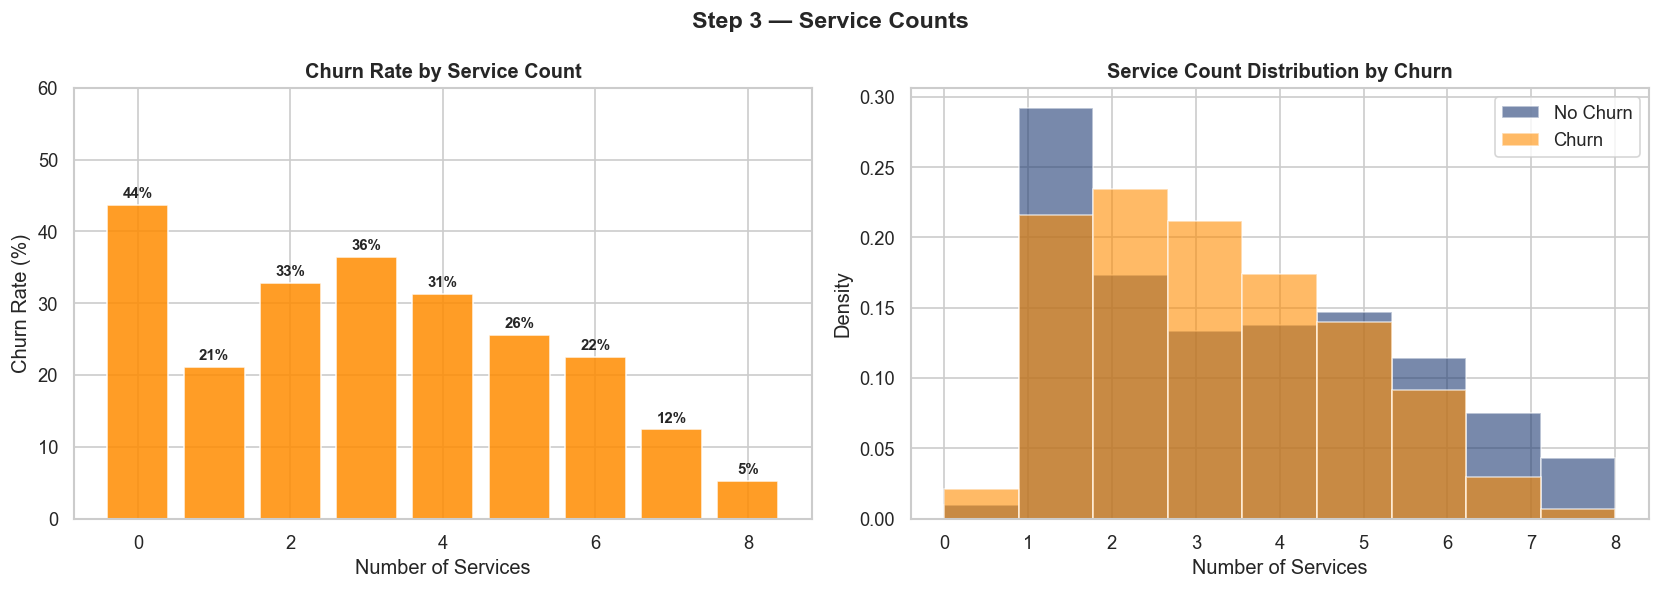

Churn rate by service count:
service_count
0.0    43.8
1.0    21.1
2.0    32.8
3.0    36.5
4.0    31.3
5.0    25.6
6.0    22.5
7.0    12.4
8.0     5.3

Avg services — No Churn: 3.45
Avg services — Churn:    3.13


In [5]:
SERVICE_COLS = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['service_count'] = (df[SERVICE_COLS] == 'Yes').sum(axis=1).astype('float32')
df['has_internet']  = (df['InternetService'] != 'No').astype('float32')
df['has_phone']     = (df['PhoneService'] == 'Yes').astype('float32')

NEW_NUMS += ['service_count', 'has_internet', 'has_phone']

# Visualize churn rate by service count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 3 — Service Counts', fontsize=14, weight='bold')

# Churn rate by service count
churn_by_service = df.groupby('service_count')['Churn'].mean() * 100
axes[0].bar(churn_by_service.index, churn_by_service.values,
            color='#FF8C00', edgecolor='white', alpha=0.85)
axes[0].set_title('Churn Rate by Service Count', weight='bold')
axes[0].set_xlabel('Number of Services')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 60)
for i, val in enumerate(churn_by_service.values):
    axes[0].text(churn_by_service.index[i], val + 1,
                f'{val:.0f}%', ha='center', fontsize=9, weight='bold')

# Distribution of service count by churn
for label, color, name in [(0, '#1f3b73', 'No Churn'), (1, '#FF8C00', 'Churn')]:
    subset = df[df['Churn'] == label]['service_count']
    axes[1].hist(subset, bins=9, alpha=0.6, color=color,
                label=name, edgecolor='white', density=True)
axes[1].set_title('Service Count Distribution by Churn', weight='bold')
axes[1].set_xlabel('Number of Services')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/fe_03_service_counts.png', dpi=150)
plt.show()

print('Churn rate by service count:')
print(churn_by_service.round(1).to_string())
print(f'\nAvg services — No Churn: {df[df["Churn"]==0]["service_count"].mean():.2f}')
print(f'Avg services — Churn:    {df[df["Churn"]==1]["service_count"].mean():.2f}')

## Step 4 — Target Encoding (ORIG_proba)

**What it does:** For each categorical and numerical variable, 
calculates the historical churn rate per group and maps it to each customer.

**Why it helps:** Converts categorical variables into meaningful 
numerical probabilities that the model can use directly.

**Example — Contract:**
- Month-to-month → 43% historical churn → ORIG_proba_Contract = 0.43
- Two year       →  3% historical churn → ORIG_proba_Contract = 0.03

**Important:** In the modeling notebook we will use cross-validation 
to avoid data leakage. Here we use the full dataset for exploration only.

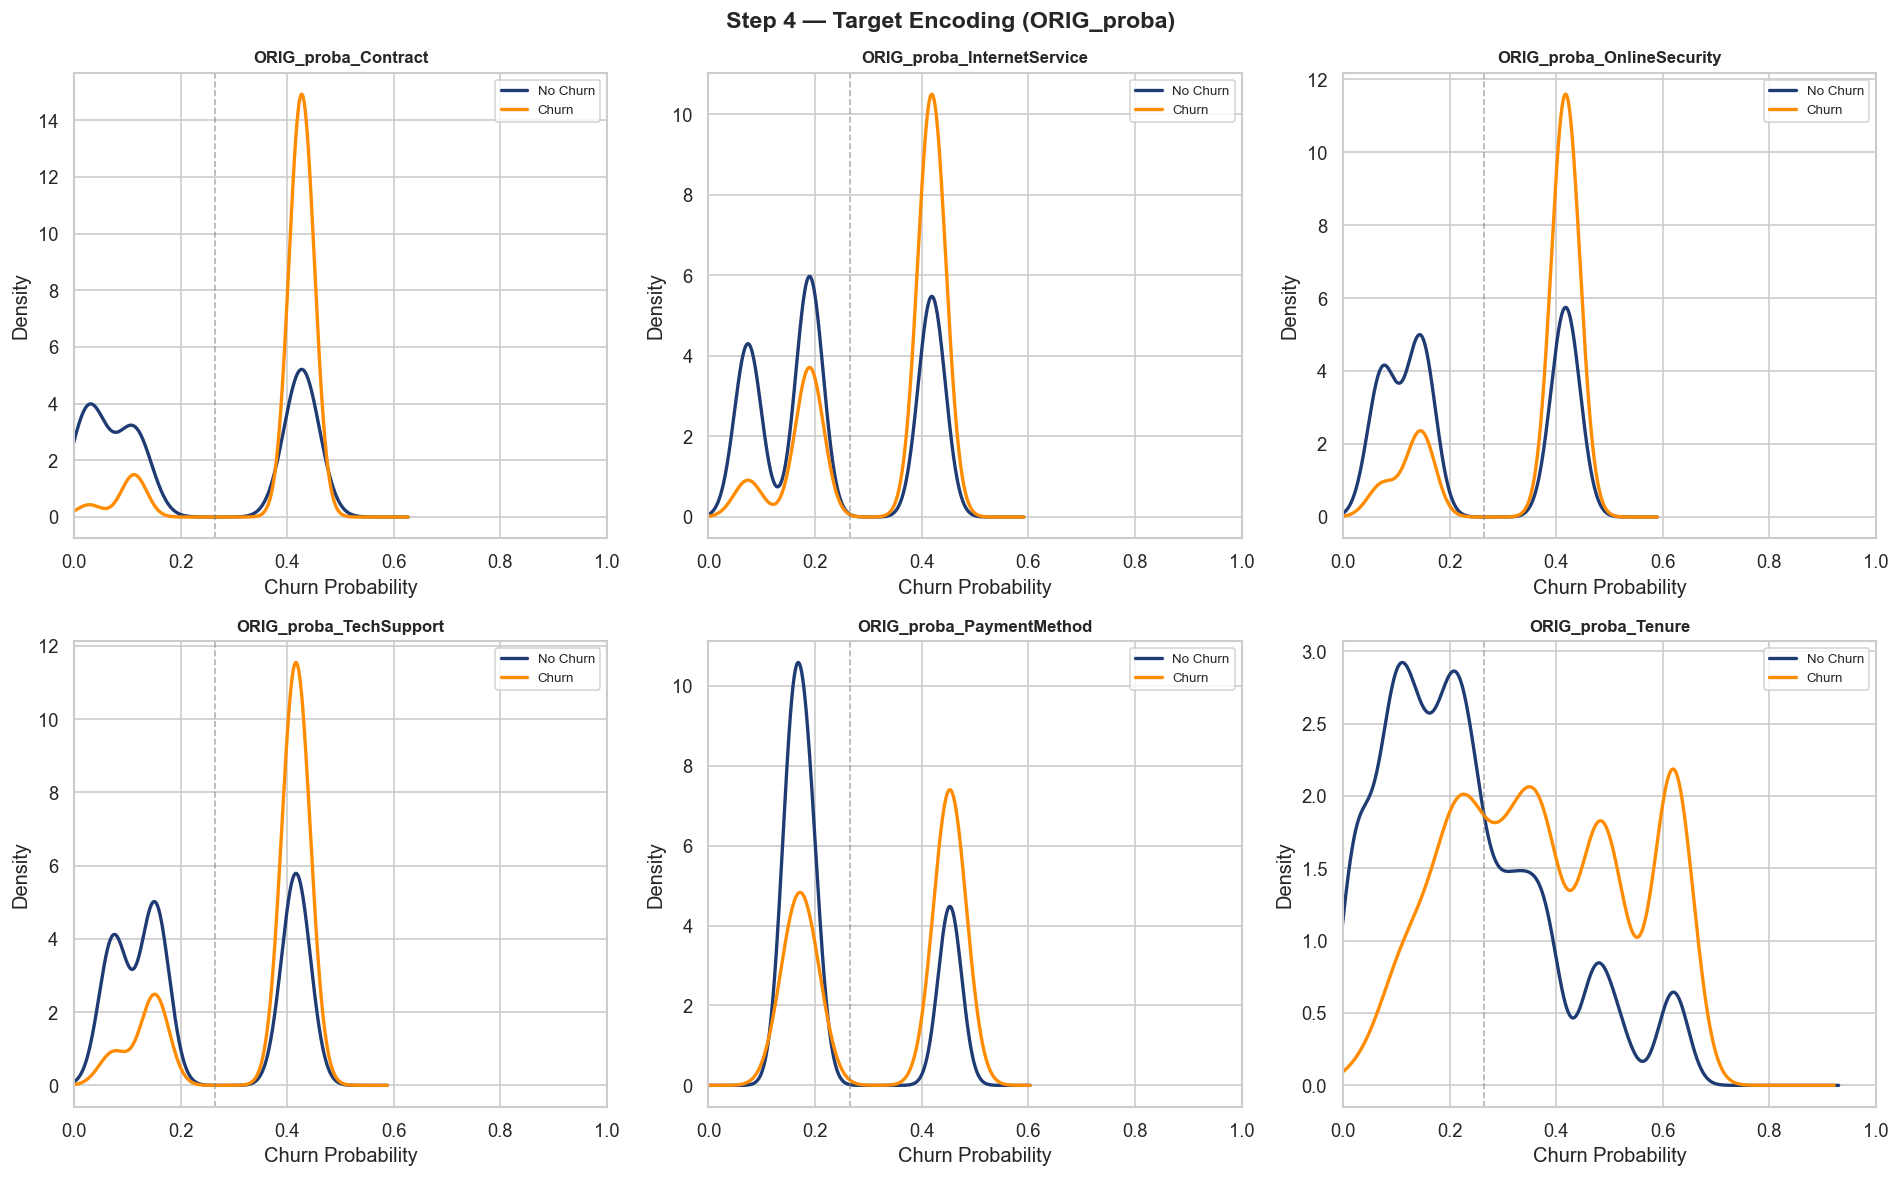

Target encoding features created: 19
Total features so far: 47


In [6]:
ORIG_PROBA_COLS = []

for col in CAT_COLS + NUM_COLS:
    tmp = df.groupby(col)['Churn'].mean()
    col_name = f'ORIG_proba_{col}'
    df[col_name] = df[col].map(tmp).fillna(0.5).astype('float32')
    ORIG_PROBA_COLS.append(col_name)
    NEW_NUMS.append(col_name)

# Visualize top 6 most separating ORIG_proba features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Step 4 — Target Encoding (ORIG_proba)', fontsize=14, weight='bold')
axes = axes.flatten()

top_cols = ['Contract', 'InternetService', 'OnlineSecurity',
            'TechSupport', 'PaymentMethod', 'Tenure']

for ax, col in zip(axes, top_cols):
    col_name = f'ORIG_proba_{col}'
    for label, color, name in [(0, '#1f3b73', 'No Churn'), (1, '#FF8C00', 'Churn')]:
        df[df['Churn'] == label][col_name].plot.kde(
            ax=ax, color=color, linewidth=2, label=name)
    ax.set_title(f'ORIG_proba_{col}', weight='bold', fontsize=10)
    ax.set_xlabel('Churn Probability')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    ax.axvline(0.265, color='gray', linestyle='--', linewidth=1,
               alpha=0.6, label='Global churn rate')

plt.tight_layout()
plt.savefig('../outputs/fe_04_target_encoding.png', dpi=150)
plt.show()

print(f'Target encoding features created: {len(ORIG_PROBA_COLS)}')
print(f'Total features so far: {len(NUM_COLS) + len(CAT_COLS) + len(NEW_NUMS)}')

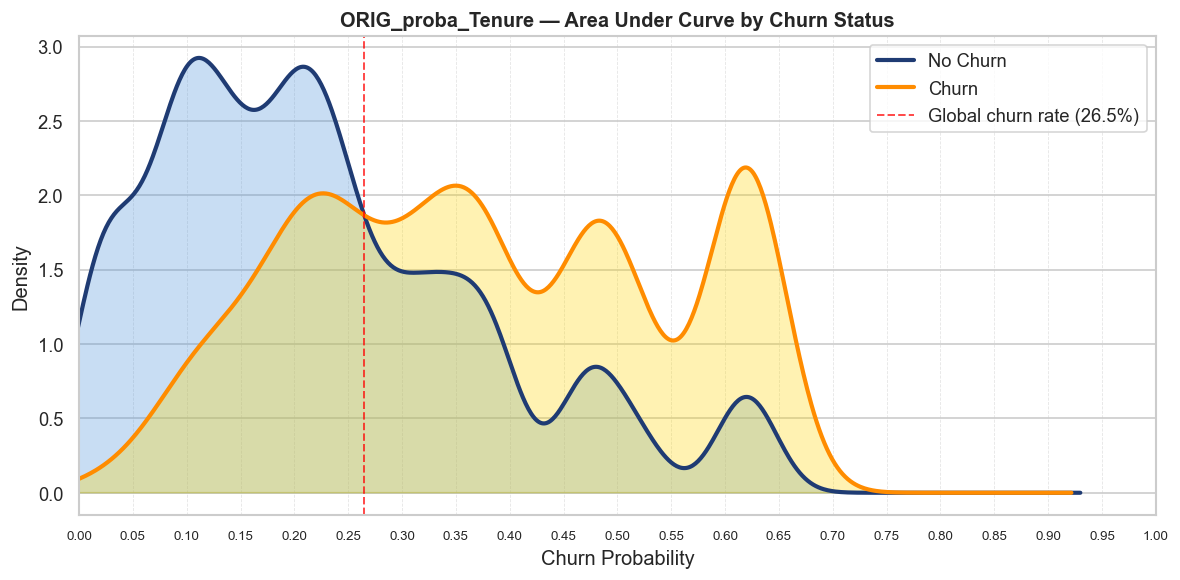

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, color, fill_color, name in [
    (0, '#1f3b73', '#4a90d9', 'No Churn'),
    (1, '#FF8C00', '#FFD700', 'Churn')
]:
    data = df[df['Churn'] == label]['ORIG_proba_Tenure']
    data.plot.kde(ax=ax, color=color, linewidth=2.5, label=name)
    x = ax.lines[-1].get_xdata()
    y = ax.lines[-1].get_ydata()
    ax.fill_between(x, y, alpha=0.30, color=fill_color)

ax.axvline(0.265, color='red', linestyle='--', linewidth=1.2,
           alpha=0.7, label='Global churn rate (26.5%)')

# Ticks cada 0.05
ax.set_xticks([round(x * 0.05, 2) for x in range(0, 21)])
ax.tick_params(axis='x', labelsize=8)
ax.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.5)

ax.set_title('ORIG_proba_Tenure — Area Under Curve by Churn Status', weight='bold')
ax.set_xlabel('Churn Probability')
ax.set_ylabel('Density')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/fe_04b_tenure_kde_filled.png', dpi=150)
plt.show()

## Step 5 — Distribution Features

**What it does:** Measures where each customer sits relative to the 
distribution of known churners and non-churners.

**Why it helps:** Instead of asking "how much does this customer pay?", 
we ask "how similar is this customer's behavior to known churners?"

| New Feature | What it captures |
|-------------|-----------------|
| `pctrank_churner_TC` | Percentile rank of TotalCharges vs churners |
| `pctrank_nonchurner_TC` | Percentile rank of TotalCharges vs non-churners |
| `pctrank_orig_TC` | Percentile rank vs full population |
| `pctrank_churn_gap_TC` | Difference between churner and non-churner ranks |
| `zscore_churn_gap_TC` | Z-score gap between churner and non-churner distributions |
| `zscore_nonchurner_TC` | Z-score vs non-churner distribution |
| `resid_IS_MC` | MonthlyCharges residual vs InternetService group mean |
| `cond_pctrank_IS_TC` | Percentile rank within InternetService group |
| `cond_pctrank_C_TC` | Percentile rank within Contract group |

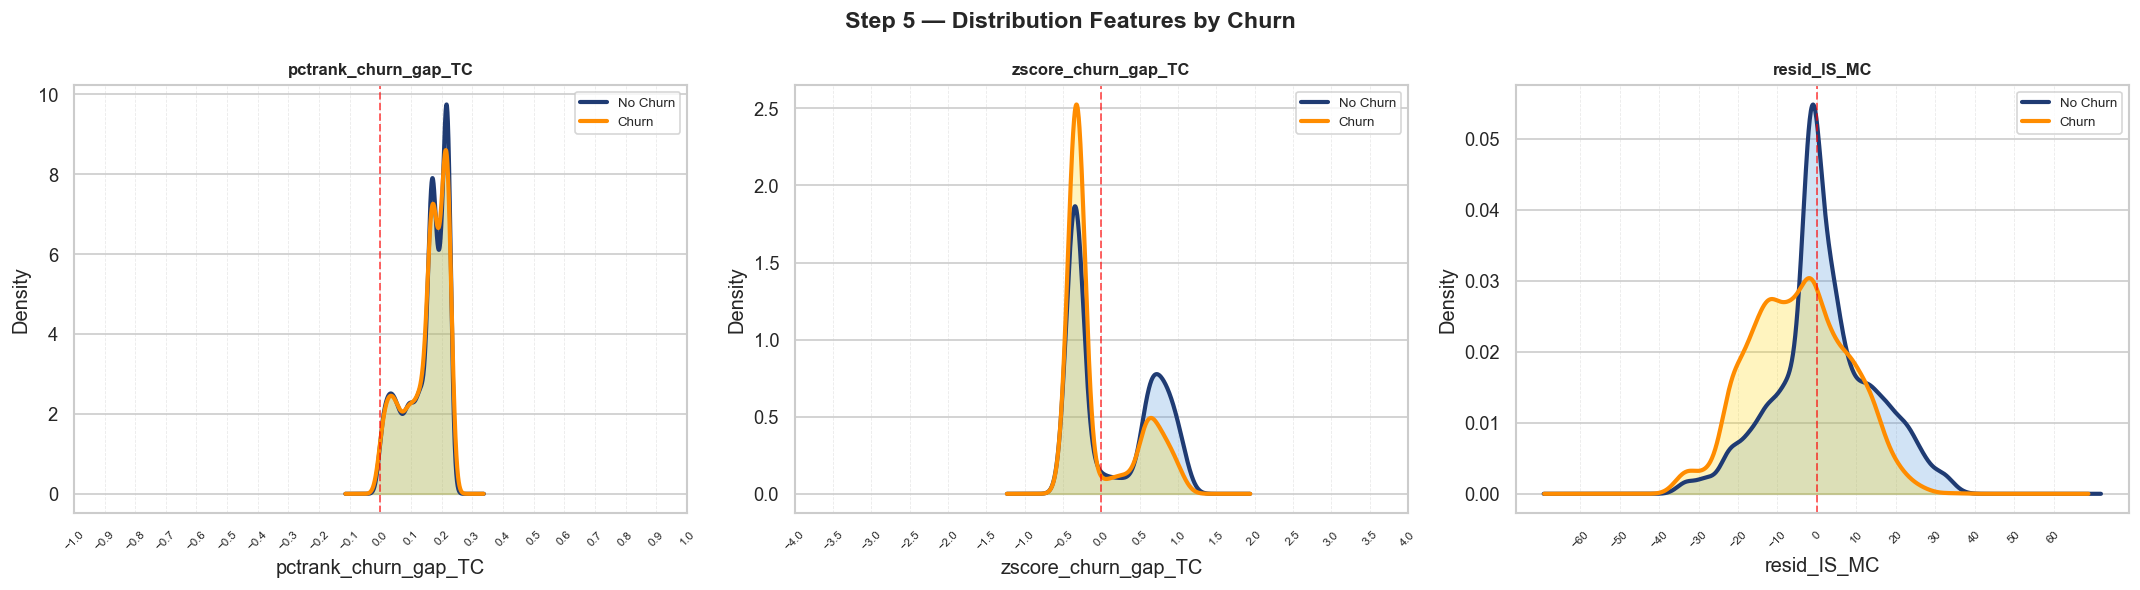

MonthlyCharges mean by InternetService group:
InternetService
DSL            58.10
Fiber optic    91.50
No             21.08

resid_IS_MC mean by Churn:
Churn
0    1.661
1   -4.599


In [11]:
# resid_IS_MC = MonthlyCharges - mean(MonthlyCharges) for that InternetService group
# Example:
#   Fiber optic avg MonthlyCharges = $91
#   Customer with Fiber optic pays $75 → resid = 75 - 91 = -16 (pays LESS than peers)
#   Customer with Fiber optic pays $110 → resid = 110 - 91 = +19 (pays MORE than peers)
#
# Why it helps: A customer paying more than peers in their internet group
# may feel overcharged → higher churn risk

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Step 5 — Distribution Features by Churn', fontsize=14, weight='bold')

plot_configs = [
    ('pctrank_churn_gap_TC', np.arange(-1.0, 1.1,  0.10)),
    ('zscore_churn_gap_TC',  np.arange(-4.0, 4.1,  0.50)),
    ('resid_IS_MC',          np.arange(-60,  61,   10.00))
]

for ax, (col, ticks) in zip(axes, plot_configs):
    for label, color, fill_color, name in [
        (0, '#1f3b73', '#4a90d9', 'No Churn'),
        (1, '#FF8C00', '#FFD700', 'Churn')
    ]:
        data = df[df['Churn'] == label][col]
        data.plot.kde(ax=ax, color=color, linewidth=2.5, label=name)
        x = ax.lines[-1].get_xdata()
        y = ax.lines[-1].get_ydata()
        ax.fill_between(x, y, alpha=0.25, color=fill_color)

    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.set_title(col, weight='bold', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.set_xticks(ticks)
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.4)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/fe_05_distribution_features.png', dpi=150)
plt.show()

# Print group means to understand resid_IS_MC
print('MonthlyCharges mean by InternetService group:')
print(df.groupby('InternetService')['MonthlyCharges'].mean().round(2).to_string())
print()
print('resid_IS_MC mean by Churn:')
print(df.groupby('Churn')['resid_IS_MC'].mean().round(3).to_string())

## Step 6 — Quantile Distance Features

**What it does:** Measures how far each customer's TotalCharges is 
from the typical TotalCharges of churners and non-churners at Q25, Q50, Q75.

**Why it helps:** Instead of asking "how much does this customer pay?",
we ask "how close is this customer to the typical churner?"

**Example — Q50 (median):**
- Churner median TotalCharges = $703
- Non-churner median TotalCharges = $1,685
- Customer with TotalCharges = $500:
  - dist_To_ch_q50 = |500 - 703| = 203  → close to churner
  - dist_To_nc_q50 = |500 - 1685| = 1185 → far from non-churner
  - qdist_gap = 1185 - 203 = +982       → positive = closer to churner

Reference Quantiles:
  Q25 — Churner: $134  |  Non-churner: $580  |  Gap: $445
  Q50 — Churner: $704  |  Non-churner: $1680  |  Gap: $976
  Q75 — Churner: $2331  |  Non-churner: $4263  |  Gap: $1932


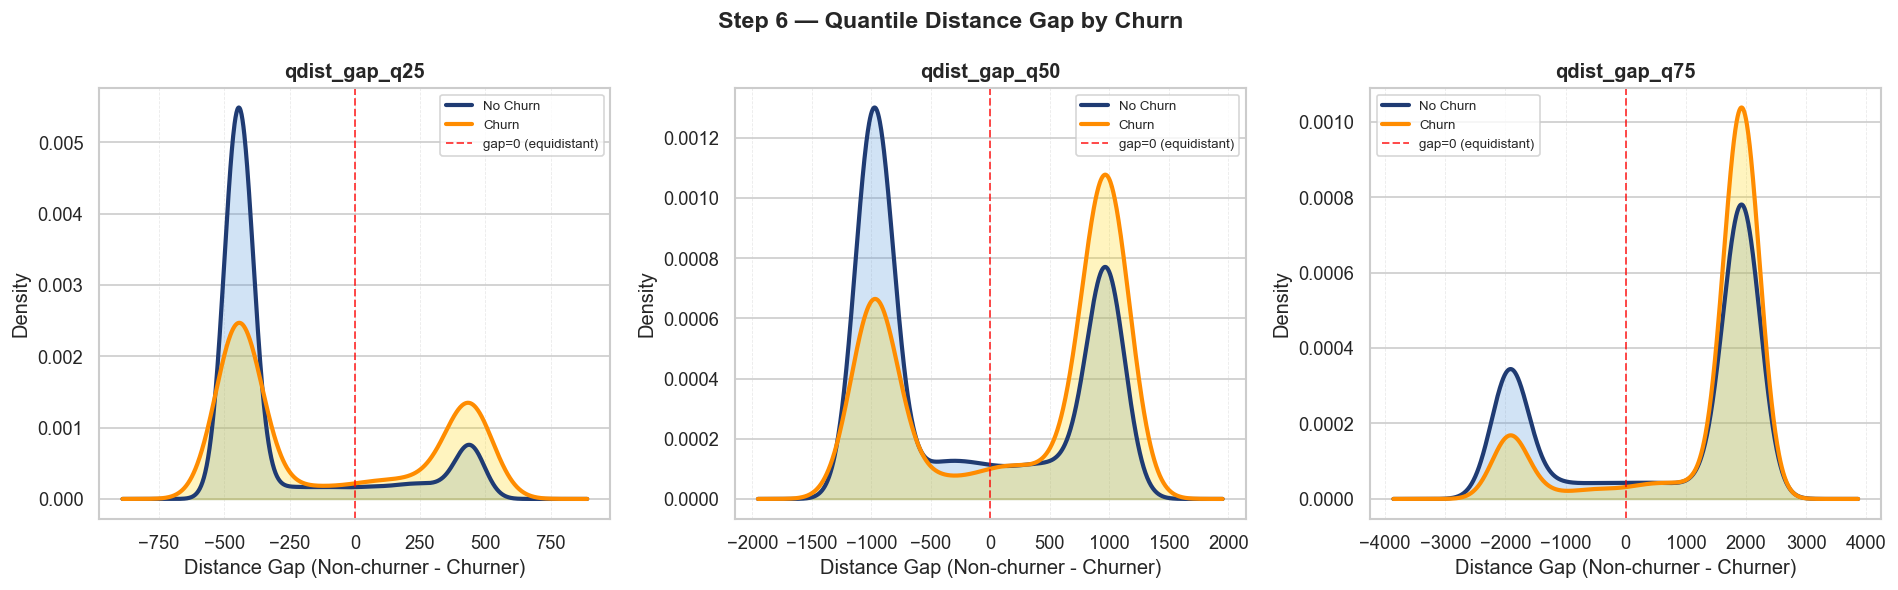


Quantile features created: 9
Total features so far: 65


In [12]:
churner_tc    = df[df['Churn'] == 1]['TotalCharges'].values
nonchurner_tc = df[df['Churn'] == 0]['TotalCharges'].values

QUANTILE_FEATURES = []

for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:
    ch_q  = np.quantile(churner_tc,    q_val)
    nc_q  = np.quantile(nonchurner_tc, q_val)

    df[f'dist_To_ch_{q_label}'] = np.abs(df['TotalCharges'] - ch_q).astype('float32')
    df[f'dist_To_nc_{q_label}'] = np.abs(df['TotalCharges'] - nc_q).astype('float32')
    df[f'qdist_gap_{q_label}']  = (df[f'dist_To_nc_{q_label}'] - 
                                    df[f'dist_To_ch_{q_label}']).astype('float32')

    QUANTILE_FEATURES += [f'dist_To_ch_{q_label}',
                          f'dist_To_nc_{q_label}',
                          f'qdist_gap_{q_label}']

NEW_NUMS += QUANTILE_FEATURES

# Print reference quantiles
print('Reference Quantiles:')
for q_label, q_val in [('Q25', 0.25), ('Q50', 0.50), ('Q75', 0.75)]:
    ch_q  = np.quantile(churner_tc,    q_val/100 if q_val > 1 else q_val)
    nc_q  = np.quantile(nonchurner_tc, q_val/100 if q_val > 1 else q_val)
    print(f'  {q_label} — Churner: ${np.quantile(churner_tc, q_val):.0f}'
          f'  |  Non-churner: ${np.quantile(nonchurner_tc, q_val):.0f}'
          f'  |  Gap: ${np.quantile(nonchurner_tc, q_val) - np.quantile(churner_tc, q_val):.0f}')

# Visualize qdist_gap for q25, q50, q75
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Step 6 — Quantile Distance Gap by Churn', fontsize=14, weight='bold')

for ax, q_label in zip(axes, ['q25', 'q50', 'q75']):
    col = f'qdist_gap_{q_label}'
    for label, color, fill_color, name in [
        (0, '#1f3b73', '#4a90d9', 'No Churn'),
        (1, '#FF8C00', '#FFD700', 'Churn')
    ]:
        data = df[df['Churn'] == label][col]
        data.plot.kde(ax=ax, color=color, linewidth=2.5, label=name)
        x = ax.lines[-1].get_xdata()
        y = ax.lines[-1].get_ydata()
        ax.fill_between(x, y, alpha=0.25, color=fill_color)

    ax.axvline(0, color='red', linestyle='--', linewidth=1.2,
               alpha=0.7, label='gap=0 (equidistant)')
    ax.set_title(f'qdist_gap_{q_label}', weight='bold')
    ax.set_xlabel('Distance Gap (Non-churner - Churner)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/fe_06_quantile_distance.png', dpi=150)
plt.show()

print(f'\nQuantile features created: {len(QUANTILE_FEATURES)}')
print(f'Total features so far: {len(NUM_COLS) + len(CAT_COLS) + len(NEW_NUMS)}')

## Step 7 — Digit Features

**What it does:** Extracts patterns from the digits of numerical variables.

**Why it helps:** In synthetic or processed datasets, digit patterns can 
reveal data generation artifacts or real behavioral patterns.

**Example — Tenure:**
- tenure=12 → tenure_mod12=0 (exactly 1 year — contract renewal point)
- tenure=24 → tenure_mod12=0 (exactly 2 years — another renewal point)
- tenure=1  → tenure_first_digit=1, tenure_num_digits=1

**Key insight:** Customers at contract renewal points (mod12=0) 
may have higher churn risk — they just finished a commitment period.

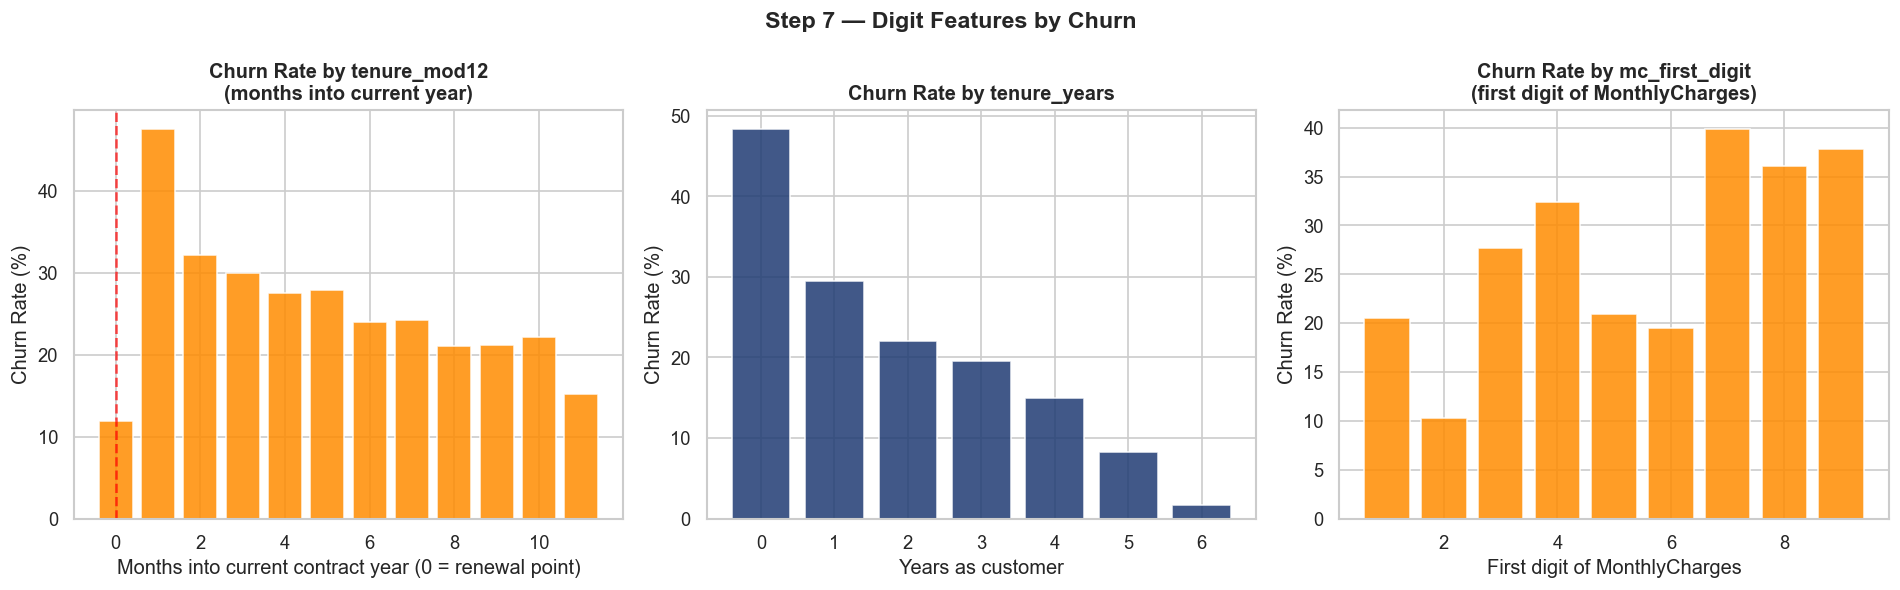

Digit features created: 32
Total features so far: 97


In [13]:
DIGIT_FEATURES = []

for df_iter in [df]:
    # --- Tenure digits ---
    t_str = df_iter['Tenure'].astype(str)
    df_iter['tenure_first_digit']      = t_str.str[0].astype(int)
    df_iter['tenure_last_digit']       = t_str.str[-1].astype(int)
    df_iter['tenure_mod10']            = df_iter['Tenure'] % 10
    df_iter['tenure_mod12']            = df_iter['Tenure'] % 12
    df_iter['tenure_num_digits']       = t_str.str.len()
    df_iter['tenure_is_multiple_10']   = (df_iter['Tenure'] % 10 == 0).astype('float32')
    df_iter['tenure_rounded_10']       = np.round(df_iter['Tenure'] / 10) * 10
    df_iter['tenure_dev_from_round10'] = np.abs(df_iter['Tenure'] - df_iter['tenure_rounded_10'])
    df_iter['tenure_years']            = df_iter['Tenure'] // 12
    df_iter['tenure_months_in_year']   = df_iter['Tenure'] % 12

    # --- MonthlyCharges digits ---
    mc_str = df_iter['MonthlyCharges'].astype(str).str.replace('.', '', regex=False)
    df_iter['mc_first_digit']        = mc_str.str[0].astype(int)
    df_iter['mc_last_digit']         = mc_str.str[-1].astype(int)
    df_iter['mc_mod10']              = np.floor(df_iter['MonthlyCharges']) % 10
    df_iter['mc_mod100']             = np.floor(df_iter['MonthlyCharges']) % 100
    df_iter['mc_num_digits']         = np.floor(df_iter['MonthlyCharges']).astype(int).astype(str).str.len()
    df_iter['mc_is_multiple_10']     = (np.floor(df_iter['MonthlyCharges']) % 10 == 0).astype('float32')
    df_iter['mc_is_multiple_50']     = (np.floor(df_iter['MonthlyCharges']) % 50 == 0).astype('float32')
    df_iter['mc_rounded_10']         = np.round(df_iter['MonthlyCharges'] / 10) * 10
    df_iter['mc_fractional']         = df_iter['MonthlyCharges'] - np.floor(df_iter['MonthlyCharges'])
    df_iter['mc_dev_from_round10']   = np.abs(df_iter['MonthlyCharges'] - df_iter['mc_rounded_10'])
    df_iter['mc_per_digit']          = df_iter['MonthlyCharges'] / (df_iter['mc_num_digits'] + 0.001)

    # --- TotalCharges digits ---
    tc_str = df_iter['TotalCharges'].astype(str).str.replace('.', '', regex=False)
    df_iter['tc_first_digit']        = tc_str.str[0].astype(int)
    df_iter['tc_last_digit']         = tc_str.str[-1].astype(int)
    df_iter['tc_mod10']              = np.floor(df_iter['TotalCharges']) % 10
    df_iter['tc_mod100']             = np.floor(df_iter['TotalCharges']) % 100
    df_iter['tc_num_digits']         = np.floor(df_iter['TotalCharges']).astype(int).astype(str).str.len()
    df_iter['tc_is_multiple_10']     = (np.floor(df_iter['TotalCharges']) % 10 == 0).astype('float32')
    df_iter['tc_is_multiple_100']    = (np.floor(df_iter['TotalCharges']) % 100 == 0).astype('float32')
    df_iter['tc_rounded_100']        = np.round(df_iter['TotalCharges'] / 100) * 100
    df_iter['tc_fractional']         = df_iter['TotalCharges'] - np.floor(df_iter['TotalCharges'])
    df_iter['tc_dev_from_round100']  = np.abs(df_iter['TotalCharges'] - df_iter['tc_rounded_100'])
    df_iter['tc_per_digit']          = df_iter['TotalCharges'] / (df_iter['tc_num_digits'] + 0.001)

DIGIT_FEATURES = [
    'tenure_first_digit', 'tenure_last_digit', 'tenure_mod10', 'tenure_mod12',
    'tenure_num_digits', 'tenure_is_multiple_10', 'tenure_rounded_10',
    'tenure_dev_from_round10', 'tenure_years', 'tenure_months_in_year',
    'mc_first_digit', 'mc_last_digit', 'mc_mod10', 'mc_mod100',
    'mc_num_digits', 'mc_is_multiple_10', 'mc_is_multiple_50',
    'mc_rounded_10', 'mc_fractional', 'mc_dev_from_round10', 'mc_per_digit',
    'tc_first_digit', 'tc_last_digit', 'tc_mod10', 'tc_mod100',
    'tc_num_digits', 'tc_is_multiple_10', 'tc_is_multiple_100',
    'tc_rounded_100', 'tc_fractional', 'tc_dev_from_round100', 'tc_per_digit'
]
NEW_NUMS += DIGIT_FEATURES

# Visualize most interpretable digit features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Step 7 — Digit Features by Churn', fontsize=14, weight='bold')

# Churn rate by tenure_mod12
churn_by_mod12 = df.groupby('tenure_mod12')['Churn'].mean() * 100
axes[0].bar(churn_by_mod12.index, churn_by_mod12.values,
            color='#FF8C00', edgecolor='white', alpha=0.85)
axes[0].set_title('Churn Rate by tenure_mod12\n(months into current year)', weight='bold')
axes[0].set_xlabel('Months into current contract year (0 = renewal point)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Churn rate by tenure_years
churn_by_years = df.groupby('tenure_years')['Churn'].mean() * 100
axes[1].bar(churn_by_years.index, churn_by_years.values,
            color='#1f3b73', edgecolor='white', alpha=0.85)
axes[1].set_title('Churn Rate by tenure_years', weight='bold')
axes[1].set_xlabel('Years as customer')
axes[1].set_ylabel('Churn Rate (%)')

# Churn rate by mc_first_digit
churn_by_mc_digit = df.groupby('mc_first_digit')['Churn'].mean() * 100
axes[2].bar(churn_by_mc_digit.index, churn_by_mc_digit.values,
            color='#FF8C00', edgecolor='white', alpha=0.85)
axes[2].set_title('Churn Rate by mc_first_digit\n(first digit of MonthlyCharges)', weight='bold')
axes[2].set_xlabel('First digit of MonthlyCharges')
axes[2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('../outputs/fe_07_digit_features.png', dpi=150)
plt.show()

print(f'Digit features created: {len(DIGIT_FEATURES)}')
print(f'Total features so far: {len(NUM_COLS) + len(CAT_COLS) + len(NEW_NUMS)}')

## Step 8 — N-gram Features (Bi-grams & Tri-grams)

**What it does:** Creates new categorical variables by combining 
2 or 3 categorical variables together.

**Why it helps:** The model can find patterns in combinations that 
don't exist in individual variables.

**Example:**
- Contract = "Month-to-month" + InternetService = "Fiber optic"
  → Bigram = "Month-to-month_Fiber optic" → churn rate = 55%
- Contract = "Two year" + InternetService = "DSL"
  → Bigram = "Two year_DSL" → churn rate = 1%

The same Contract value behaves very differently depending on 
which InternetService the customer has.


C:\Users\danip\AppData\Local\Temp\ipykernel_13324\4135350354.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = (df[c1].astype(str) + '_' +
C:\Users\danip\AppData\Local\Temp\ipykernel_13324\4135350354.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = (df[c1].astype(str) + '_' +


Bi-gram features:  15
Tri-gram features: 4


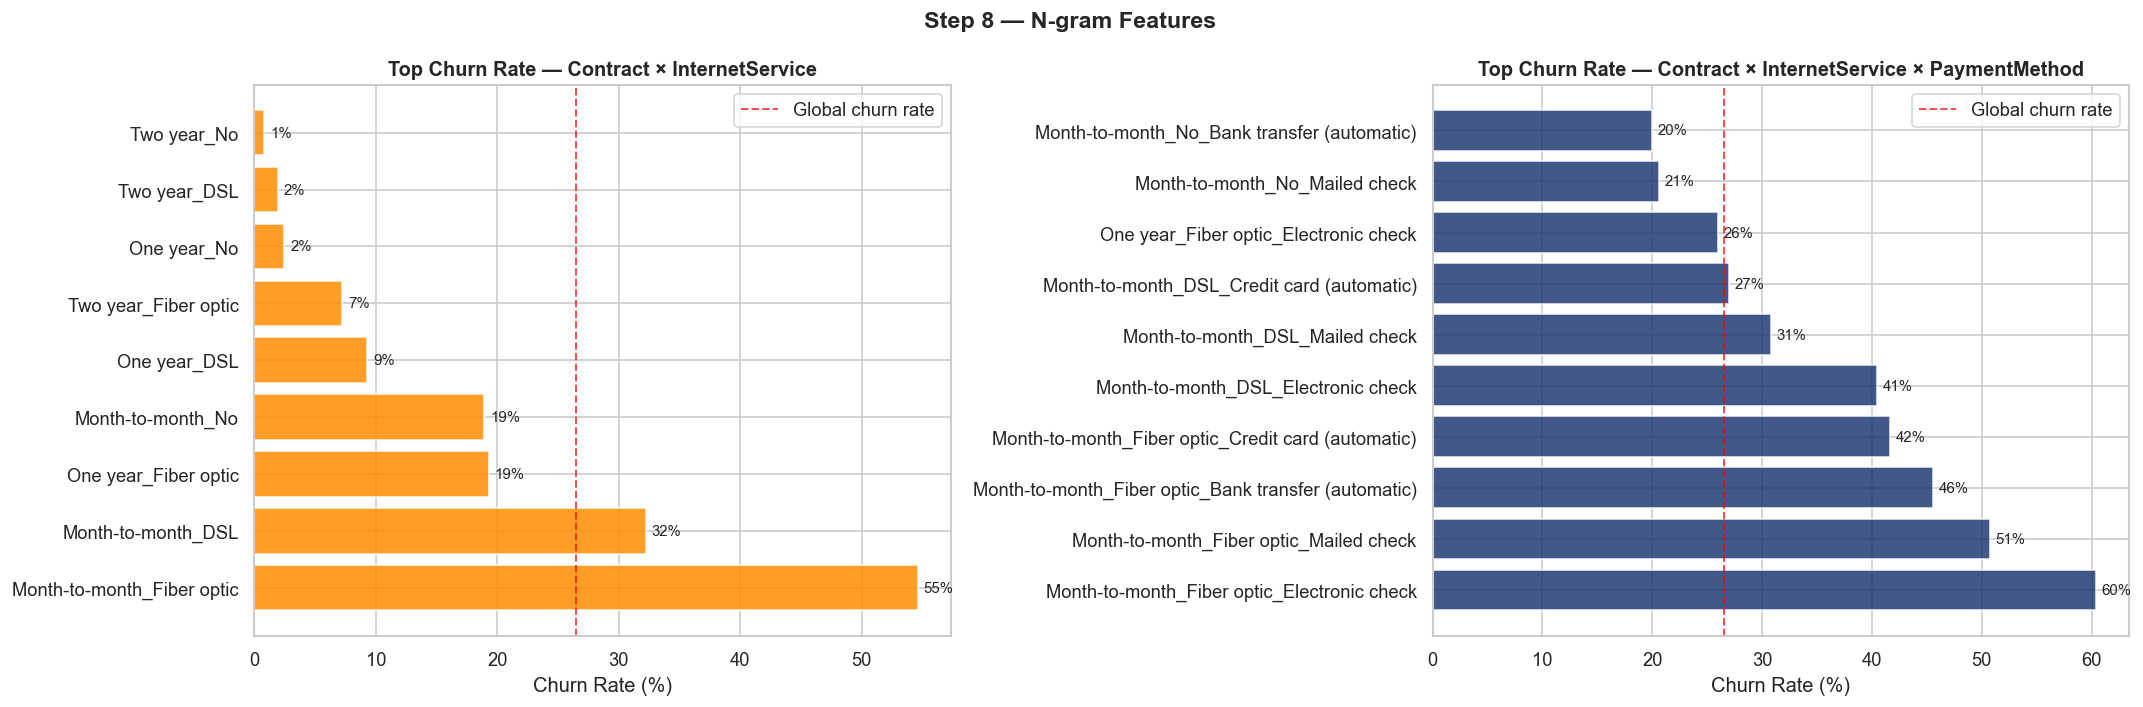


Total features so far: 118


In [14]:
from itertools import combinations

TOP_CATS_FOR_NGRAM = [
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
]

BIGRAM_COLS  = []
TRIGRAM_COLS = []

# Bi-grams — all pairs
for c1, c2 in combinations(TOP_CATS_FOR_NGRAM, 2):
    col_name = f'BG_{c1}_{c2}'
    df[col_name] = (df[c1].astype(str) + '_' + df[c2].astype(str))
    BIGRAM_COLS.append(col_name)

# Tri-grams — top 4 variables only
TOP4 = TOP_CATS_FOR_NGRAM[:4]
for c1, c2, c3 in combinations(TOP4, 3):
    col_name = f'TG_{c1}_{c2}_{c3}'
    df[col_name] = (df[c1].astype(str) + '_' + 
                    df[c2].astype(str) + '_' + 
                    df[c3].astype(str))
    TRIGRAM_COLS.append(col_name)

print(f'Bi-gram features:  {len(BIGRAM_COLS)}')
print(f'Tri-gram features: {len(TRIGRAM_COLS)}')

# Visualize top 10 most risky bigram combinations
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Step 8 — N-gram Features', fontsize=14, weight='bold')

# Top 10 highest churn rate bigrams
bg_churn = df.groupby('BG_Contract_InternetService')['Churn'].agg(['mean', 'count'])
bg_churn.columns = ['churn_rate', 'count']
bg_churn = bg_churn[bg_churn['count'] >= 50].sort_values('churn_rate', ascending=False).head(10)
bg_churn['churn_rate_pct'] = bg_churn['churn_rate'] * 100

bars = axes[0].barh(bg_churn.index, bg_churn['churn_rate_pct'],
                    color='#FF8C00', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, bg_churn['churn_rate_pct']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}%', va='center', fontsize=9)
axes[0].set_title('Top Churn Rate — Contract × InternetService', weight='bold')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].axvline(26.5, color='red', linestyle='--', linewidth=1.2,
                alpha=0.7, label='Global churn rate')
axes[0].legend()

# Top 10 highest churn rate trigrams
tg_churn = df.groupby('TG_Contract_InternetService_PaymentMethod')['Churn'].agg(['mean', 'count'])
tg_churn.columns = ['churn_rate', 'count']
tg_churn = tg_churn[tg_churn['count'] >= 30].sort_values('churn_rate', ascending=False).head(10)
tg_churn['churn_rate_pct'] = tg_churn['churn_rate'] * 100

bars = axes[1].barh(tg_churn.index, tg_churn['churn_rate_pct'],
                    color='#1f3b73', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, tg_churn['churn_rate_pct']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}%', va='center', fontsize=9)
axes[1].set_title('Top Churn Rate — Contract × InternetService × PaymentMethod',
                  weight='bold')
axes[1].set_xlabel('Churn Rate (%)')
axes[1].axvline(26.5, color='red', linestyle='--', linewidth=1.2,
                alpha=0.7, label='Global churn rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/fe_08_ngram_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal features so far: {len(df.columns)}')

## 9. Feature Engineering Summary

All 8 steps completed. Here is a consolidated view of what was built
and why each step matters for the model.

In [15]:
print('=' * 65)
print('FEATURE ENGINEERING SUMMARY — TELCO CUSTOMER CHURN')
print('=' * 65)

print(f'\nOriginal Features:')
print(f'  Numerical:              {len(NUM_COLS)}')
print(f'  Categorical:            {len(CAT_COLS)}')
print(f'  Total original:         {len(NUM_COLS) + len(CAT_COLS)}')

print(f'\nEngineered Features:')
print(f'  Step 1 — Freq Encoding:       {len([c for c in NEW_NUMS if c.startswith("FREQ")])}')
print(f'  Step 2 — Arithmetic:          3')
print(f'  Step 3 — Service Counts:      3')
print(f'  Step 4 — Target Encoding:     {len(ORIG_PROBA_COLS)}')
print(f'  Step 5 — Distribution:        {len(DIST_FEATURES)}')
print(f'  Step 6 — Quantile Distance:   {len(QUANTILE_FEATURES)}')
print(f'  Step 7 — Digit Features:      {len(DIGIT_FEATURES)}')
print(f'  Step 8 — Bi-grams:            {len(BIGRAM_COLS)}')
print(f'  Step 8 — Tri-grams:           {len(TRIGRAM_COLS)}')
print(f'  Total engineered:             {len(NEW_NUMS) + len(BIGRAM_COLS) + len(TRIGRAM_COLS)}')

print(f'\nTotal columns in dataset:    {len(df.columns)}')

print(f'\nKey Findings:')
print(f'  → Month-to-month + Fiber optic + Electronic check = 60% churn')
print(f'  → tenure_mod12=1 has highest churn rate (47%) — just after renewal')
print(f'  → monthly_to_total_ratio 3x higher in churners (0.30 vs 0.10)')
print(f'  → Contract is strongest single predictor (39.9pp spread)')
print(f'  → Tenure is strongest numerical predictor (corr=-0.35)')

print(f'\nNext Step → 03_modeling.ipynb')
print('=' * 65)

FEATURE ENGINEERING SUMMARY — TELCO CUSTOMER CHURN

Original Features:
  Numerical:              3
  Categorical:            16
  Total original:         19

Engineered Features:
  Step 1 — Freq Encoding:       3
  Step 2 — Arithmetic:          3
  Step 3 — Service Counts:      3
  Step 4 — Target Encoding:     19
  Step 5 — Distribution:        9
  Step 6 — Quantile Distance:   9
  Step 7 — Digit Features:      32
  Step 8 — Bi-grams:            15
  Step 8 — Tri-grams:           4
  Total engineered:             97

Total columns in dataset:    118

Key Findings:
  → Month-to-month + Fiber optic + Electronic check = 60% churn
  → tenure_mod12=1 has highest churn rate (47%) — just after renewal
  → monthly_to_total_ratio 3x higher in churners (0.30 vs 0.10)
  → Contract is strongest single predictor (39.9pp spread)
  → Tenure is strongest numerical predictor (corr=-0.35)

Next Step → 03_modeling.ipynb
